# Clase 2 - EDA
__DATA DETECTIVE__
  
__Objetivo:__ Realizar un análisis exploratorio de datos para encontrar patrones, relaciones y observaciones interesantes.  
__Challenge:__ Encontrar al menos cinco hallazgos importantas dentro del data set

## FASE 1 -Auditoria  
Reportar:  
> - dimensiones  
> - tipos  
> - valores flotantes  
> - duplicados  
> - valores únicos  


In [2]:
import pandas as pd 
df_dective = pd.read_csv("reto_detective.csv")
df_dective.head(10)

,id_usuario,edad,ciudad,plataforma,pedidos_mes,gasto_mensual,tiempo_entrega_min,calificacion
0,1025,27,Guadalajara,Android,3,345.71,53.6,4.6
1,1003,51,cdmx,android,6,1142.04,155.0,3.5
2,1073,31,Puebla,ios,2,314.15,44.7,4.8
3,1171,41,cdmx,iOS,4,569.15,36.8,4.5
4,1047,19,Puebla,iOS,6,756.61,35.4,4.4
5,1112,32,GDL,Android,3,391.00,30.6,4.4
6,1006,48,Guadalajara,NaN,9,1922.35,38.7,4.4
7,1146,21,CDMX,Android,7,1498.43,34.6,4.9
8,1082,53,Ciudad de México,Android,5,1146.84,42.1,5.0
9,1064,54,cdmx,ios,3,421.75,24.5,3.8


In [3]:
#dimensiones del dataframe
print("Dimensiones del dataframe:", df_dective.shape)

Dimensiones del dataframe: (186, 8)


In [4]:
#Los tipos de datos de cada columna
df_dective.info()

<class 'pandas.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_usuario          186 non-null    int64  
 1   edad                186 non-null    int64  
 2   ciudad              176 non-null    str    
 3   plataforma          181 non-null    str    
 4   pedidos_mes         186 non-null    int64  
 5   gasto_mensual       180 non-null    float64
 6   tiempo_entrega_min  186 non-null    float64
 7   calificacion        177 non-null    float64
dtypes: float64(3), int64(3), str(2)
memory usage: 11.8 KB


In [5]:
#Valores faltantes en cada columna
missing_values = df_dective.isnull().sum()
print("Valores faltantes por columna:\n", missing_values)

Valores faltantes por columna:
 id_usuario             0
edad                   0
ciudad                10
plataforma             5
pedidos_mes            0
gasto_mensual          6
tiempo_entrega_min     0
calificacion           9
dtype: int64


In [6]:
# Valores duplicados en el dataframe
duplicate_rows = df_dective[df_dective.duplicated()]
print("Número de filas duplicadas:", duplicate_rows.shape[0])

Número de filas duplicadas: 6


In [7]:
df_dective.nunique()

id_usuario            180
edad                   39
ciudad                  8
plataforma              4
pedidos_mes            11
gasto_mensual         174
tiempo_entrega_min    137
calificacion           23
dtype: int64

In [8]:
#Observamos através de la fila anterior que tnemos duplicados, por lo que eliminaremos los duplicados
df_dective = df_dective.drop_duplicates()

Conclusiones Fase 1:  
> 

## Fase 2 - Distribuciones  
Selecionar al menos tres variables númericas, para cada una:   
> - media  
> - mediana  
> - desviación estandar   
> - mínimo  
> - máximo  
> - cuartiles  


In [9]:
#Seleccionamos las tres columans que nos interesan para el análisis
df_dective_F2 = df_dective[['gasto_mensual', 'tiempo_entrega_min', 'calificacion']]
df_dective_F2.head(5)

,gasto_mensual,tiempo_entrega_min,calificacion
0,345.71,53.6,4.6
1,1142.04,155.0,3.5
2,314.15,44.7,4.8
3,569.15,36.8,4.5
4,756.61,35.4,4.4


In [10]:
#Teneninedo nuestras tres variables de interés, realizaremos los estasdísticos descriptivos de cada una de ellas, para ello utilizaremos la función describe() de pandas
print("La media del gasto_mensual es:", df_dective_F2['gasto_mensual'].mean())
print("La media del tiempo_entrega_min es:", df_dective_F2['tiempo_entrega_min'].mean())
print("La media de la calificacion es:", df_dective_F2['calificacion'].mean())    

La media del gasto_mensual es: 1084.6748850574713
La media del tiempo_entrega_min es: 33.43555555555556
La media de la calificacion es: 4.219883040935673


In [11]:
#Obtendremos la mediana de las variables seleccionadas
print("La mediana del gasto_mensual es:", df_dective_F2['gasto_mensual'].median())
print("La mediana del tiempo_entrega_min es:", df_dective_F2['tiempo_entrega_min'].median())
print("La mediana de la calificacion es:", df_dective_F2['calificacion'].median())

La mediana del gasto_mensual es: 996.675
La mediana del tiempo_entrega_min es: 31.5
La mediana de la calificacion es: 4.2


In [12]:
#Obtendremos la desviacon estandar de las variables seleccionadas
print("La desviación estándar del gasto_mensual es:", df_dective_F2['gasto_mensual'].std())
print("La desviación estándar del tiempo_entrega_min es:", df_dective_F2['tiempo_entrega_min'].std())
print("La desviación estándar de la calificacion es:", df_dective_F2['calificacion'].std())

La desviación estándar del gasto_mensual es: 602.6079224050762
La desviación estándar del tiempo_entrega_min es: 14.89787065217588
La desviación estándar de la calificacion es: 0.6059139798238629


In [13]:
# El minimo y máximo de cada variable seleccionada, realizaremos un agruppado 
agrupado_variables = df_dective_F2.agg(['min', 'max'])
print("Mínimo y máximo de las variables seleccionadas:\n", agrupado_variables)


Mínimo y máximo de las variables seleccionadas:
      gasto_mensual  tiempo_entrega_min  calificacion
min         229.73               -12.0           2.9
max        4200.00               155.0           7.0


In [14]:
#Obtendremos los cuartiles de las variables seleccionadas
cuartiles = df_dective_F2.quantile([0.25, 0.5, 0.75])
print("Cuartiles de las variables seleccionadas:\n", cuartiles)

Cuartiles de las variables seleccionadas:
       gasto_mensual  tiempo_entrega_min  calificacion
0.25        677.730              26.875          3.75
0.50        996.675              31.500          4.20
0.75       1309.035              37.900          4.70


Conclusiones Fase 2  


## FASE 3 - Variables Categóricas  
Seleccionar al menos dos variables categóricas.  
Analizar:  
> - categoría más frecuente  
> - categoria menos frecuente  
> - posibles desbalances  

In [15]:
df_dective_categoricas = df_dective[['ciudad','plataforma']]

In [16]:
#Categoria más frecuente en las variables seleccionadas
categoria_frecuente = df_dective_categoricas[['ciudad', 'plataforma']].mode().iloc[0]
categoria_frecuente

ciudad        Ciudad de México
plataforma             Android
Name: 0, dtype: str

In [17]:
#Categoria menos frecuente en las variables seleccionadas
categoria_menos_frecuente = df_dective_categoricas[['ciudad', 'plataforma']].value_counts().idxmin()    
categoria_menos_frecuente

('Puebla', 'ios')

In [18]:
#Agrupado de las variables categóricas para obtener la frecuencia de cada categoría
frecuencia_categorias_plataforma = df_dective_categoricas.groupby(['plataforma']).size()
frecuencia_categorias_plataforma

plataforma
Android    79
android    15
iOS        69
ios        12
dtype: int64

In [19]:
#Agrupado de las variables categóricas para obtener la frecuencia de cada categoría
frecuencia_categorias_ciudad = df_dective_categoricas.groupby(['ciudad']).size()
frecuencia_categorias_ciudad    

ciudad
CDMX                15
Ciudad de México    27
GDL                 19
Guadalajara         27
Monterrey           23
Puebla              22
cdmx                19
puebla              18
dtype: int64

In [24]:
#Modificacion de las variables categoricas, ya que se encontró que venian con diferente formato, por lo que se estandarizaron a mayusculas
df_dective["plataforma"] = df_dective["plataforma"].str.strip().str.upper()
df_dective["ciudad"] = df_dective["ciudad"].str.strip().str.upper()



In [28]:
#Estarizar las variables 
def agrupar_ciudad(ciudad):
    if pd.isna(ciudad):
        return ciudad

    if ciudad in ["CDMX", "CIUDAD DE MÉXICO"]:
        return "CDMX"

    elif ciudad in ["GDL", "GUADALAJARA"]:
        return "GUADALAJARA"

    else:
        return ciudad

df_dective["ciudad"] = df_dective["ciudad"].apply(agrupar_ciudad)

In [30]:
#Actualizando nuevamente la  base de datos con las variables categoricas
df_dective_categoricas = df_dective[['ciudad','plataforma']]

In [32]:
#Ahora se realizará la correción sobre las variables categóricas, ya que se encontró que venian con diferente formato, por lo que se estandarizaron a mayusculas
frecuencia_categorias_ciudad = df_dective_categoricas.groupby(['ciudad']).size()
frecuencia_categorias_ciudad.sort_values(ascending=False)

ciudad
CDMX           61
GUADALAJARA    46
PUEBLA         40
MONTERREY      23
dtype: int64

In [33]:
#Agrupado de las variables categóricas para obtener la frecuencia de cada categoría
frecuencia_categorias_plataforma = df_dective_categoricas.groupby(['plataforma']).size()
frecuencia_categorias_plataforma

plataforma
ANDROID    94
IOS        81
dtype: int64

No se observa un desbalance significatico en las variebles categoricas: ciudad y plataforma. Las frecuencias de estas categorías son relativamente similares, por lo que ninguna domina de forma considerable sobre las otras.

## Fase 4 - Relaciones  
Investigar al menos:  
> - Una relación numérica-numérica.  
> - Una relación categórica - numérica.  
> - Una relación categórica - categórica (si el dataset lo permite). 

In [36]:
df_dective

,id_usuario,edad,ciudad,plataforma,pedidos_mes,gasto_mensual,tiempo_entrega_min,calificacion
0,1025,27,GUADALAJARA,ANDROID,3,345.71,53.6,4.6
1,1003,51,CDMX,ANDROID,6,1142.04,155.0,3.5
2,1073,31,PUEBLA,IOS,2,314.15,44.7,4.8
3,1171,41,CDMX,IOS,4,569.15,36.8,4.5
4,1047,19,PUEBLA,IOS,6,756.61,35.4,4.4
...,...,...,...,...,...,...,...,...
181,1021,29,GUADALAJARA,IOS,7,1660.72,38.4,4.1
182,1000,52,GUADALAJARA,ANDROID,5,893.47,27.4,4.1
183,1131,26,PUEBLA,ANDROID,5,1021.46,33.8,4.1
184,1152,35,CDMX,ANDROID,4,275.15,25.3,4.5


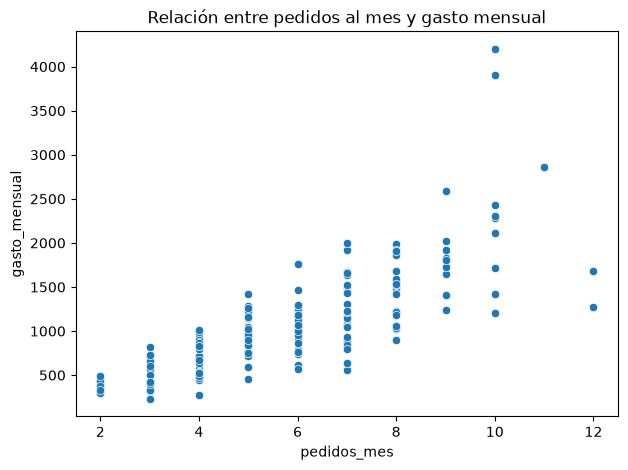

In [ ]:
#Relación númerica - númerica
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.scatterplot(data=df_dective, x="pedidos_mes", y="gasto_mensual")

plt.title("Relación entre pedidos al mes y gasto mensual")
plt.show()

In [40]:
df_dective[["pedidos_mes", "gasto_mensual"]].corr()

,pedidos_mes,gasto_mensual
pedidos_mes,1.000000,0.783592
gasto_mensual,0.783592,1.000000


En esta gráfica podemos observar una relación positiva entre el número de pedidos mensuales y gasto mensual. Podemos ver que a medida que los usuarios realizan más pedidos tienden a presentar un gasto elevado. De igual manera obsevamos algunos valores atípicos con gastos superiores al resto.
Asímismo se confirma mediante el coeficiente de correlación de Pearson, cuyo valor es de 0.784. El resultado indica una correlación positiva moderadamente fuerte entre ambas variables, lo que sugiere que un mayor número de pedidos suele estar asociado con un mayor gasto mensual.

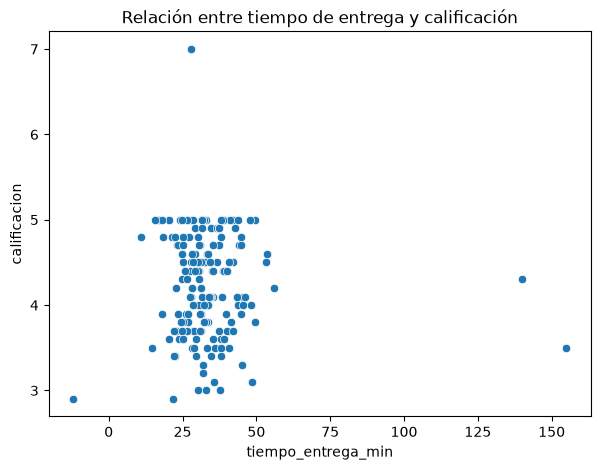

In [46]:
#Relación númerica - númerica

plt.figure(figsize=(7,5))

sns.scatterplot(data=df_dective, x="tiempo_entrega_min", y="calificacion")

plt.title("Relación entre tiempo de entrega y calificación")
plt.show()

Inicialmente se esperaba que un menor tiempo de entrega estuviera asociado con mejores calificaciones, el análisis no evidenció una relación lineal entre estas variables. Esto sugiere que la satisfacción del usuario podría depender de otros factores además del tiempo de entrega.

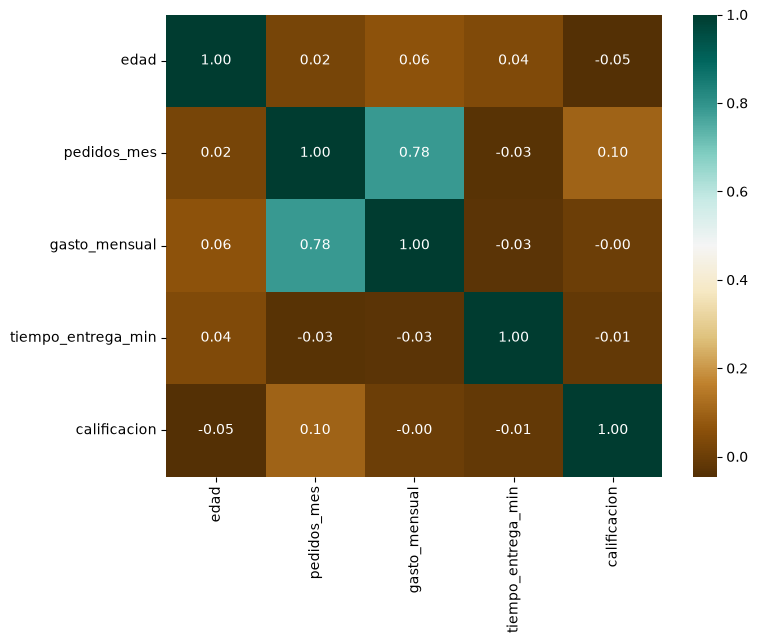

In [49]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_dective.drop(columns=['id_usuario']).corr(numeric_only=True),
    annot=True,
    cmap="BrBG",
    fmt=".2f"
)

plt.show()

Hallazgos con mapa de calor 

> - **Pedidos vs. Gasto mensual:** 0.78.  
> Correlación positiva moderadamente fuerte.  

> - **Pedidos vs. Calificación:** 0.10.   
> correlación muy débil.  

> - **Edad vs. Pedidos:** 0.02.  
> Sin relación. 

> - **Tiempo de entrega vs. Gasto mensual:** -0.03.  
> Sin relación lineal. 

> - **Tiempo de entrega vs. Calificación:** -0.01   
>Sin relación lineal. 

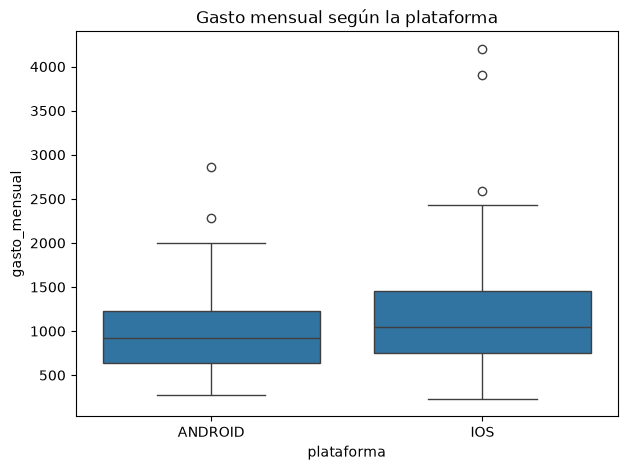

In [43]:
#Relación categórica - númerica
plt.figure(figsize=(7,5))

sns.boxplot(data=df_dective, x="plataforma", y="gasto_mensual")

plt.title("Gasto mensual según la plataforma")
plt.show()


En el boxplot se observa como los usuarios de iOS tienden a presentar un gasto mensual ligeramente superior a los de Android.. En ambos tenemos valores a t+ipicos. 

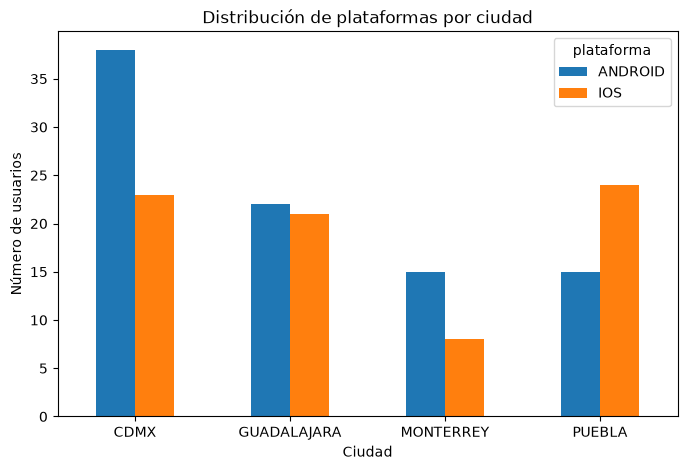

In [44]:
#Relación categórica - categórica
tabla = pd.crosstab(df_dective["ciudad"], df_dective["plataforma"])

tabla.plot(kind="bar", figsize=(8,5))

plt.title("Distribución de plataformas por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=0)
plt.show()

En esta distribución podemos observar que la cantidad de usuarios de Android e iOS cambia dependiendo de la ciudad. CDMX es la ciudad con mayor concentración de usuarios de Android, mientras que en Puebla predominan los usuarios de iOS. En Guadalajara ambas plataformas tienen una cantidad de usuarios muy similar y, por último, Monterrey es la ciudad con menos usuarios registrados.

## Fase 5 - Los 5 Hallazgos  
Presentar cinco conclusiones como:  

“El grupo X presenta un promedio de ventas mayor que el grupo Y.”  
Cada hallazgo deberá estar acompañado por evidencia.


1.¿Cuál fue el hallazgo más sorprendente?   
> El hallazago con más importancia fue la realción positiva entre el núme de pedidos mensuales y gasto mensual. El coeficiente de correlación de Pearson (0.78) mostro esta asociación es fuerte, lo que demuestra que los usuarios que realizan más pedidos tienden a gastar más.  

2.¿Entontraste algún dato sospechoso?  
> Si, se encontraro valores atípicos en la variable gasto mensual, principalmente en usuarios con 10 pedidos al mes, los cuales fueron superiores al resto.  

3.¿Qué variables investigarías con mayor profundidad?  
> La variable gasto_mensual, ya que presento variabilidad y algunos valores atípicos. Se podría ver la relación con la ciudad o plataforma utilizada.

4.¿Qué hipótesis surgió durante el EDA?  
> Una posible hipótesis es que los usuarios que realizan un mayor número de pedidos al mes tienden a presentar un gasto mensual más alto. Otra podría plantearse que la plataforma utilizada (Android o iOS) no influye de manera importante en el gasto mensual, ya que ambas muestran distribuciones similares.



### __Cinco Hallazgos__

> - **Calidad de los datos**  
> Durante la auditoría del dataset se identificaron valores faltantes en algunas variables, diferencias en el formato de las variables categóricas, por ejemplo, el uso de abreviaturas y nombres completos para la misma ciudad. Estas incosistencias fueron corregidas por medio de la estandarización de los valores.

> - **Distribución de las variable categóricas**  
> Después de la limpieza de los datos, se observó que las variables ciudad y plataforma presentan una distribución relativamente equilibrada. Aunque CDMX concentra el mayor número de registros y Monterrey el menor, no se identificó un desbalance importante entre las categorías.

> - **Relación entre pedidos y gasto mensual**    
> Se encontró una relación positiva entre el número de pedidos realizados al mes y el gasto mensual. El coeficiente de correlación de Pearson fue de 0.784, lo que indica una correlación positiva moderadamente fuerte; es decir, conforme aumenta el número de pedidos, el gasto mensual también tiende a incrementarse.

> - **Diferencias entre plataformas**  
> El análisis con boxplot mostró que los usuarios de iOS presentan una mediana de gasto ligeramente superior a la de Android y una mayor variabilidad en sus gastos. Además, en iOS se identificaron valores atípicos de mayor magnitud.

> - **Distribución por ciudad y plataforma**  
> La relación entre las variables ciudad y plataforma mostró que la cantidad de usuarios de Android e iOS varía entre ciudades. CDMX concentra más usuarios de Android, mientras que Puebla presenta una mayor cantidad de usuarios de iOS.

## __Conclusión Final__

El análisis exploratorio permitió comprender la estructura y calidad del conjunto de datos antes de aplicar modelos o técnicas más avanzadas. Durante el proceso se identificaron y corrigieron inconsistencias en las variables categóricas, además de revisar los valores faltantes y la distribución de las variables. Asimismo, se observó una relación positiva entre el número de pedidos y el gasto mensual, así como diferencias en la distribución del gasto entre plataformas y ciudades. En general, el conjunto de datos presenta una calidad adecuada para continuar con análisis más profundos o con el desarrollo de modelos predictivos, aunque sería recomendable investigar con mayor detalle los valores atípicos detectados en la variable gasto_mensual y evaluar si corresponden a clientes de alto consumo o a posibles anomalías.